# 05 — Tree-Based Valuation Models

## Plate Value Intelligence

This notebook evaluates non-linear tree-based models for predicting DVLA auction hammer prices.

### Objectives

- Preserve the approved event-based validation design
- Reuse the governed, leakage-safe feature set
- Train non-linear valuation models
- Compare performance against Ridge regression and rule-based baselines
- Analyse premium-asset prediction weaknesses
- Select the strongest candidate for final holdout testing

### Modelling principle

Model selection will use the B277 validation event only. The B278 test event remains untouched until the final model and configuration have been selected.

In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

In [5]:
PROJECT_ROOT = Path.cwd()

FEATURE_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "plate_features_2025.csv"
)

REPORTS_DIR = PROJECT_ROOT / "reports"

print(f"Feature file exists: {FEATURE_FILE.exists()}")

Feature file exists: True


In [8]:
df = pd.read_csv(FEATURE_FILE)

validation_group_map = {
    "B270": "train",
    "B271": "train",
    "B272": "train",
    "B273": "train",
    "B274": "train",
    "B275": "train",
    "B276": "train",
    "B277": "validation",
    "B278": "test",
}

df["model_split"] = df["event_code"].map(validation_group_map)

missing_split_events = sorted(
    df.loc[df["model_split"].isna(), "event_code"].dropna().unique()
)
if missing_split_events:
    raise ValueError(f"Missing model_split mapping for events: {missing_split_events}")

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
print(f"Model splits: {sorted(df['model_split'].unique())}")

Rows: 17,782
Columns: 76
Model splits: ['test', 'train', 'validation']


## 1. Event-Based Split Validation

The approved chronological event split is validated before any model training.

In [9]:
expected_split_map = {
    "B270": "train",
    "B271": "train",
    "B272": "train",
    "B273": "train",
    "B274": "train",
    "B275": "train",
    "B276": "train",
    "B277": "validation",
    "B278": "test",
}

actual_split_map = (
    df[["event_code", "model_split"]]
    .drop_duplicates()
    .set_index("event_code")["model_split"]
    .to_dict()
)

assert actual_split_map == expected_split_map, (
    "Event-based split does not match the approved design."
)

print("Event-based split is correct.")

Event-based split is correct.


In [10]:
train_df = df[df["model_split"].eq("train")].copy()
validation_df = df[df["model_split"].eq("validation")].copy()
test_df = df[df["model_split"].eq("test")].copy()

print(f"Train rows: {len(train_df):,}")
print(f"Validation rows: {len(validation_df):,}")
print(f"Test rows: {len(test_df):,}")

Train rows: 13,824
Validation rows: 1,977
Test rows: 1,981


## 2. Leakage-Safe Predictor Set

Only pre-sale structural features are used as predictors. Price-derived premium labels, targets, identifiers, and source-governance fields are excluded.

In [12]:
TARGET_COLUMN = "log_hammer_price"
RAW_PRICE_COLUMN = "hammer_price_gbp"

NUMERIC_FEATURES = [
    "plate_length",
    "letter_count",
    "digit_count",
    "numeric_length",
    "numeric_value",
    "unique_character_count",
    "repeated_character_count",
    "maximum_character_run",
    "segment_count",
    "first_segment_length",
    "last_segment_length",
    "block_count",
    "longest_block_length",
    "first_numeric_value",
    "last_numeric_value",
    "low_number_score",
    "is_single_digit_number",
    "is_two_digit_number",
    "is_number_below_100",
    "is_number_below_1000",
    "has_repeated_digit",
    "has_repeated_letter",
    "all_digits_same",
    "all_letters_same",
    "is_palindrome",
    "has_sequential_pattern",
    "is_short_plate_len_3_or_less",
    "is_short_plate_len_4_or_less",
    "is_round_number",
    "is_milestone_number",
]

CATEGORICAL_FEATURES = [
    "plate_pattern",
    "plate_format_group",
]

MODEL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

In [13]:
missing_features = [
    column
    for column in MODEL_FEATURES
    if column not in df.columns
]

assert not missing_features, (
    f"Missing model features: {missing_features}"
)

for forbidden_column in [
    "hammer_price_gbp",
    "log_hammer_price",
    "is_premium_top_10pct",
    "is_premium_top_5pct",
    "is_premium_top_1pct",
]:
    assert forbidden_column not in MODEL_FEATURES

print("Feature set passed leakage checks.")

Feature set passed leakage checks.


In [14]:
X_train = train_df[MODEL_FEATURES].copy()
X_validation = validation_df[MODEL_FEATURES].copy()
X_test = test_df[MODEL_FEATURES].copy()

y_train = train_df[TARGET_COLUMN].copy()
y_validation = validation_df[TARGET_COLUMN].copy()
y_test = test_df[TARGET_COLUMN].copy()

print(f"X_train: {X_train.shape}")
print(f"X_validation: {X_validation.shape}")
print(f"X_test: {X_test.shape}")

X_train: (13824, 32)
X_validation: (1977, 32)
X_test: (1981, 32)


In [15]:
def evaluate_price_predictions(
    actual_prices,
    predicted_prices,
    model_name,
    dataset_name,
):
    actual_prices = np.asarray(actual_prices, dtype=float)
    predicted_prices = np.asarray(predicted_prices, dtype=float)

    predicted_prices = np.clip(
        predicted_prices,
        a_min=0,
        a_max=None,
    )

    return {
        "model": model_name,
        "dataset": dataset_name,
        "mae_gbp": mean_absolute_error(
            actual_prices,
            predicted_prices,
        ),
        "median_absolute_error_gbp": median_absolute_error(
            actual_prices,
            predicted_prices,
        ),
        "rmse_gbp": np.sqrt(
            mean_squared_error(
                actual_prices,
                predicted_prices,
            )
        ),
        "log_rmse": np.sqrt(
            mean_squared_error(
                np.log1p(actual_prices),
                np.log1p(predicted_prices),
            )
        ),
    }

In [16]:
tree_numeric_preprocessor = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median"),
        ),
    ]
)

tree_categorical_preprocessor = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent"),
        ),
        (
            "one_hot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
        ),
    ]
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            tree_numeric_preprocessor,
            NUMERIC_FEATURES,
        ),
        (
            "categorical",
            tree_categorical_preprocessor,
            CATEGORICAL_FEATURES,
        ),
    ],
    remainder="drop",
)

## 3. Random Forest Valuation Model

Random Forest can learn non-linear relationships and interactions without requiring those interactions to be manually specified.

In [17]:
random_forest_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            tree_preprocessor,
        ),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                max_depth=14,
                min_samples_leaf=5,
                max_features="sqrt",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

In [18]:
random_forest_pipeline.fit(
    X_train,
    y_train,
)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [19]:
rf_validation_predictions_log = (
    random_forest_pipeline.predict(
        X_validation
    )
)

rf_validation_predictions_gbp = np.expm1(
    rf_validation_predictions_log
)

rf_validation_predictions_gbp = np.clip(
    rf_validation_predictions_gbp,
    a_min=0,
    a_max=None,
)

In [20]:
tree_model_results = []

tree_model_results.append(
    evaluate_price_predictions(
        actual_prices=validation_df[
            RAW_PRICE_COLUMN
        ],
        predicted_prices=rf_validation_predictions_gbp,
        model_name="random_forest",
        dataset_name="validation",
    )
)

tree_model_results_df = pd.DataFrame(
    tree_model_results
)

tree_model_results_df

,model,dataset,mae_gbp,median_absolute_error_gbp,rmse_gbp,log_rmse
0,random_forest,validation,"1,230.53",638.05,"2,348.75",0.75


## 4. Histogram Gradient Boosting Model

Histogram Gradient Boosting builds trees sequentially, with each new tree focusing on errors made by the previous trees. It is evaluated as a stronger non-linear candidate for plate valuation.

In [21]:
hist_gradient_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            tree_preprocessor,
        ),
        (
            "model",
            HistGradientBoostingRegressor(
                learning_rate=0.05,
                max_iter=300,
                max_leaf_nodes=31,
                min_samples_leaf=20,
                l2_regularization=1.0,
                random_state=42,
            ),
        ),
    ]
)

In [22]:
hist_gradient_pipeline.fit(
    X_train,
    y_train,
)

print("Histogram Gradient Boosting trained successfully.")

Histogram Gradient Boosting trained successfully.


In [23]:
hgb_validation_predictions_log = (
    hist_gradient_pipeline.predict(
        X_validation
    )
)

hgb_validation_predictions_gbp = np.expm1(
    hgb_validation_predictions_log
)

hgb_validation_predictions_gbp = np.clip(
    hgb_validation_predictions_gbp,
    a_min=0,
    a_max=None,
)

In [24]:
tree_model_results.append(
    evaluate_price_predictions(
        actual_prices=validation_df[
            RAW_PRICE_COLUMN
        ],
        predicted_prices=hgb_validation_predictions_gbp,
        model_name="hist_gradient_boosting",
        dataset_name="validation",
    )
)

tree_model_results_df = pd.DataFrame(
    tree_model_results
)

tree_model_results_df.sort_values(
    "mae_gbp"
)

,model,dataset,mae_gbp,median_absolute_error_gbp,rmse_gbp,log_rmse
1,hist_gradient_boosting,validation,"1,228.31",647.85,"2,352.89",0.75
0,random_forest,validation,"1,230.53",638.05,"2,348.75",0.75


In [25]:
BASELINE_REPORT_FILE = (
    REPORTS_DIR
    / "baseline_model_comparison_2025.csv"
)

baseline_model_results = pd.read_csv(
    BASELINE_REPORT_FILE
)

baseline_model_results

,model,dataset,mae_gbp,median_absolute_error_gbp,rmse_gbp,log_rmse,mae_improvement_vs_median_pct
0,ridge_regression,validation,"1,258.66",644.31,"2,395.99",0.77,29.54
1,plate_length_median_baseline,validation,"1,454.39",800.00,"2,609.39",0.89,18.58
2,training_median_baseline,validation,"1,786.38","1,010.00","3,114.95",1.05,0.00


In [26]:
all_validation_results = pd.concat(
    [
        baseline_model_results[
            baseline_model_results[
                "dataset"
            ].eq("validation")
        ],
        tree_model_results_df,
    ],
    ignore_index=True,
)

all_validation_results = (
    all_validation_results
    .sort_values("mae_gbp")
    .reset_index(drop=True)
)

all_validation_results

,model,dataset,mae_gbp,median_absolute_error_gbp,rmse_gbp,log_rmse,mae_improvement_vs_median_pct
0,hist_gradient_boosting,validation,"1,228.31",647.85,"2,352.89",0.75,NaN
1,random_forest,validation,"1,230.53",638.05,"2,348.75",0.75,NaN
2,ridge_regression,validation,"1,258.66",644.31,"2,395.99",0.77,29.54
3,plate_length_median_baseline,validation,"1,454.39",800.00,"2,609.39",0.89,18.58
4,training_median_baseline,validation,"1,786.38","1,010.00","3,114.95",1.05,0.00


In [27]:
median_baseline_mae = (
    all_validation_results.loc[
        all_validation_results[
            "model"
        ].eq("training_median_baseline"),
        "mae_gbp",
    ]
    .iloc[0]
)

all_validation_results[
    "mae_improvement_vs_median_pct"
] = (
    (
        median_baseline_mae
        - all_validation_results[
            "mae_gbp"
        ]
    )
    / median_baseline_mae
    * 100
)

all_validation_results

,model,dataset,mae_gbp,median_absolute_error_gbp,rmse_gbp,log_rmse,mae_improvement_vs_median_pct
0,hist_gradient_boosting,validation,"1,228.31",647.85,"2,352.89",0.75,31.24
1,random_forest,validation,"1,230.53",638.05,"2,348.75",0.75,31.12
2,ridge_regression,validation,"1,258.66",644.31,"2,395.99",0.77,29.54
3,plate_length_median_baseline,validation,"1,454.39",800.00,"2,609.39",0.89,18.58
4,training_median_baseline,validation,"1,786.38","1,010.00","3,114.95",1.05,0.00


## 5. Validation Error and Premium-Asset Analysis

The two leading tree models are compared across price bands and premium-asset segments before a final candidate is selected.

In [28]:
validation_predictions = validation_df[
    [
        "event_code",
        "lot_number",
        "plate_raw",
        "plate_length",
        RAW_PRICE_COLUMN,
    ]
].copy()

validation_predictions[
    "random_forest_prediction_gbp"
] = rf_validation_predictions_gbp

validation_predictions[
    "hist_gradient_prediction_gbp"
] = hgb_validation_predictions_gbp

for model_column in [
    "random_forest_prediction_gbp",
    "hist_gradient_prediction_gbp",
]:
    model_prefix = model_column.replace(
        "_prediction_gbp",
        "",
    )

    validation_predictions[
        f"{model_prefix}_absolute_error_gbp"
    ] = (
        validation_predictions[RAW_PRICE_COLUMN]
        - validation_predictions[model_column]
    ).abs()

    validation_predictions[
        f"{model_prefix}_residual_gbp"
    ] = (
        validation_predictions[RAW_PRICE_COLUMN]
        - validation_predictions[model_column]
    )

validation_predictions.head()

,event_code,lot_number,plate_raw,plate_length,hammer_price_gbp,random_forest_prediction_gbp,hist_gradient_prediction_gbp,random_forest_absolute_error_gbp,random_forest_residual_gbp,hist_gradient_absolute_error_gbp,hist_gradient_residual_gbp
13824,B277,1,106 A,4,"20,510.00","14,033.80","15,475.13","6,476.20","6,476.20","5,034.87","5,034.87"
13825,B277,2,1971 A,5,"5,630.00","5,596.34","5,777.25",33.66,33.66,147.25,-147.25
13826,B277,3,972 AA,5,"4,110.00","5,417.27","5,292.03","1,307.27","-1,307.27","1,182.03","-1,182.03"
13827,B277,4,1981 AA,6,"3,410.00","3,848.28","4,041.87",438.28,-438.28,631.87,-631.87
13828,B277,5,AAA 101A,7,"1,030.00","1,230.79","2,072.04",200.79,-200.79,"1,042.04","-1,042.04"


In [29]:
price_bins = [
    0,
    1_000,
    2_500,
    5_000,
    10_000,
    np.inf,
]

price_labels = [
    "£0–£999",
    "£1,000–£2,499",
    "£2,500–£4,999",
    "£5,000–£9,999",
    "£10,000+",
]

validation_predictions[
    "actual_price_band"
] = pd.cut(
    validation_predictions[
        RAW_PRICE_COLUMN
    ],
    bins=price_bins,
    labels=price_labels,
    right=False,
)

In [30]:
def summarise_model_by_price_band(
    prediction_data,
    prediction_column,
    model_name,
):
    error_column = (
        prediction_column.replace(
            "_prediction_gbp",
            "_absolute_error_gbp",
        )
    )

    residual_column = (
        prediction_column.replace(
            "_prediction_gbp",
            "_residual_gbp",
        )
    )

    summary = (
        prediction_data
        .groupby(
            "actual_price_band",
            observed=True,
        )
        .agg(
            plate_count=("plate_raw", "size"),
            actual_median_price=(
                RAW_PRICE_COLUMN,
                "median",
            ),
            predicted_median_price=(
                prediction_column,
                "median",
            ),
            mae_gbp=(
                error_column,
                "mean",
            ),
            median_absolute_error_gbp=(
                error_column,
                "median",
            ),
            median_residual_gbp=(
                residual_column,
                "median",
            ),
        )
        .reset_index()
    )

    summary.insert(
        0,
        "model",
        model_name,
    )

    return summary

In [31]:
rf_price_band_summary = (
    summarise_model_by_price_band(
        validation_predictions,
        "random_forest_prediction_gbp",
        "random_forest",
    )
)

hgb_price_band_summary = (
    summarise_model_by_price_band(
        validation_predictions,
        "hist_gradient_prediction_gbp",
        "hist_gradient_boosting",
    )
)

tree_price_band_summary = pd.concat(
    [
        rf_price_band_summary,
        hgb_price_band_summary,
    ],
    ignore_index=True,
)

tree_price_band_summary

,model,actual_price_band,plate_count,actual_median_price,predicted_median_price,mae_gbp,median_absolute_error_gbp,median_residual_gbp
0,random_forest,£0–£999,660,500.00,812.94,467.31,394.23,-389.61
1,random_forest,"£1,000–£2,499",622,"1,510.00","1,331.39",645.93,495.85,56.97
2,random_forest,"£2,500–£4,999",424,"3,415.00","2,645.24","1,409.99","1,333.17",929.49
3,random_forest,"£5,000–£9,999",218,"6,115.00","3,457.74","2,950.80","2,665.67","2,584.32"
4,random_forest,"£10,000+",53,"12,560.00","4,869.79","9,083.83","8,371.93","8,371.93"
5,hist_gradient_boosting,£0–£999,660,500.00,836.84,464.86,380.58,-373.95
6,hist_gradient_boosting,"£1,000–£2,499",622,"1,510.00","1,339.96",642.44,513.12,60.84
7,hist_gradient_boosting,"£2,500–£4,999",424,"3,415.00","2,677.07","1,384.82","1,311.47",913.98
8,hist_gradient_boosting,"£5,000–£9,999",218,"6,115.00","3,331.02","3,000.19","2,736.71","2,704.92"
9,hist_gradient_boosting,"£10,000+",53,"12,560.00","5,042.00","9,070.94","8,534.82","8,534.82"


In [32]:
premium_threshold = validation_df[
    RAW_PRICE_COLUMN
].quantile(0.90)

premium_count = max(
    1,
    int(np.ceil(
        len(validation_predictions) * 0.10
    )),
)

validation_predictions[
    "actual_top_10pct"
] = (
    validation_predictions[
        RAW_PRICE_COLUMN
    ]
    .ge(premium_threshold)
    .astype(int)
)

print(
    f"Validation premium threshold: "
    f"£{premium_threshold:,.2f}"
)
print(
    f"Actual premium plates: "
    f"{validation_predictions['actual_top_10pct'].sum():,}"
)

Validation premium threshold: £5,684.00
Actual premium plates: 198


In [33]:
def calculate_top_decile_capture(
    prediction_data,
    prediction_column,
    model_name,
):
    predicted_premium_indices = (
        prediction_data[
            prediction_column
        ]
        .nlargest(premium_count)
        .index
    )

    actual_premium_indices = (
        prediction_data.loc[
            prediction_data[
                "actual_top_10pct"
            ].eq(1)
        ]
        .index
    )

    correctly_captured = len(
        set(predicted_premium_indices)
        & set(actual_premium_indices)
    )

    return {
        "model": model_name,
        "actual_premium_count": len(
            actual_premium_indices
        ),
        "predicted_premium_slots": premium_count,
        "correctly_captured": correctly_captured,
        "premium_recall_pct": (
            correctly_captured
            / len(actual_premium_indices)
            * 100
        ),
        "premium_precision_pct": (
            correctly_captured
            / premium_count
            * 100
        ),
    }

In [34]:
premium_capture_summary = pd.DataFrame(
    [
        calculate_top_decile_capture(
            validation_predictions,
            "random_forest_prediction_gbp",
            "random_forest",
        ),
        calculate_top_decile_capture(
            validation_predictions,
            "hist_gradient_prediction_gbp",
            "hist_gradient_boosting",
        ),
    ]
)

premium_capture_summary

,model,actual_premium_count,predicted_premium_slots,correctly_captured,premium_recall_pct,premium_precision_pct
0,random_forest,198,198,101,51.01,51.01
1,hist_gradient_boosting,198,198,98,49.49,49.49


In [35]:
rf_worst_underpredictions = (
    validation_predictions
    .sort_values(
        "random_forest_residual_gbp",
        ascending=False,
    )
    .head(20)
)

rf_worst_underpredictions[
    [
        "plate_raw",
        RAW_PRICE_COLUMN,
        "random_forest_prediction_gbp",
        "random_forest_residual_gbp",
    ]
]

,plate_raw,hammer_price_gbp,random_forest_prediction_gbp,random_forest_residual_gbp
13992,AUT 15M,"30,010.00","1,297.36","28,712.64"
15177,PAD 5L,"25,000.00","1,695.43","23,304.57"
14557,HMZ 4,"25,160.00","4,408.36","20,751.64"
15134,303 O,"30,010.00","9,675.73","20,334.27"
14564,HO75 PUR,"20,020.00","1,551.73","18,468.27"
14097,11 BUX,"22,250.00","4,806.81","17,443.19"
14718,JSK 8,"20,120.00","4,375.62","15,744.38"
15714,296 X,"25,010.00","9,589.27","15,420.73"
14799,KR75 HNA,"16,970.00","1,551.73","15,418.27"
14028,520 BB,"20,010.00","5,437.47","14,572.53"


In [36]:
hgb_worst_underpredictions = (
    validation_predictions
    .sort_values(
        "hist_gradient_residual_gbp",
        ascending=False,
    )
    .head(20)
)

hgb_worst_underpredictions[
    [
        "plate_raw",
        RAW_PRICE_COLUMN,
        "hist_gradient_prediction_gbp",
        "hist_gradient_residual_gbp",
    ]
]

,plate_raw,hammer_price_gbp,hist_gradient_prediction_gbp,hist_gradient_residual_gbp
13992,AUT 15M,"30,010.00","1,289.02","28,720.98"
15177,PAD 5L,"25,000.00","1,737.15","23,262.85"
14557,HMZ 4,"25,160.00","4,124.88","21,035.12"
15134,303 O,"30,010.00","9,902.23","20,107.77"
14564,HO75 PUR,"20,020.00","1,227.95","18,792.05"
14097,11 BUX,"22,250.00","4,366.46","17,883.54"
14718,JSK 8,"20,120.00","4,167.67","15,952.33"
15714,296 X,"25,010.00","9,236.72","15,773.28"
14799,KR75 HNA,"16,970.00","1,227.95","15,742.05"
14010,AYD 9N,"16,010.00","1,767.76","14,242.24"


In [37]:
rf_feature_names = (
    random_forest_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

rf_feature_importance = pd.DataFrame(
    {
        "feature": rf_feature_names,
        "importance": (
            random_forest_pipeline
            .named_steps["model"]
            .feature_importances_
        ),
    }
).sort_values(
    "importance",
    ascending=False,
)

rf_feature_importance.head(25)

,feature,importance
53,categorical__plate_format_group_digits_then_letters,0.14
0,numeric__plate_length,0.10
11,numeric__block_count,0.08
1,numeric__letter_count,0.08
54,categorical__plate_format_group_letters_digits_letters,0.07
4,numeric__numeric_value,0.05
14,numeric__last_numeric_value,0.05
13,numeric__first_numeric_value,0.05
27,numeric__is_short_plate_len_4_or_less,0.04
9,numeric__first_segment_length,0.04


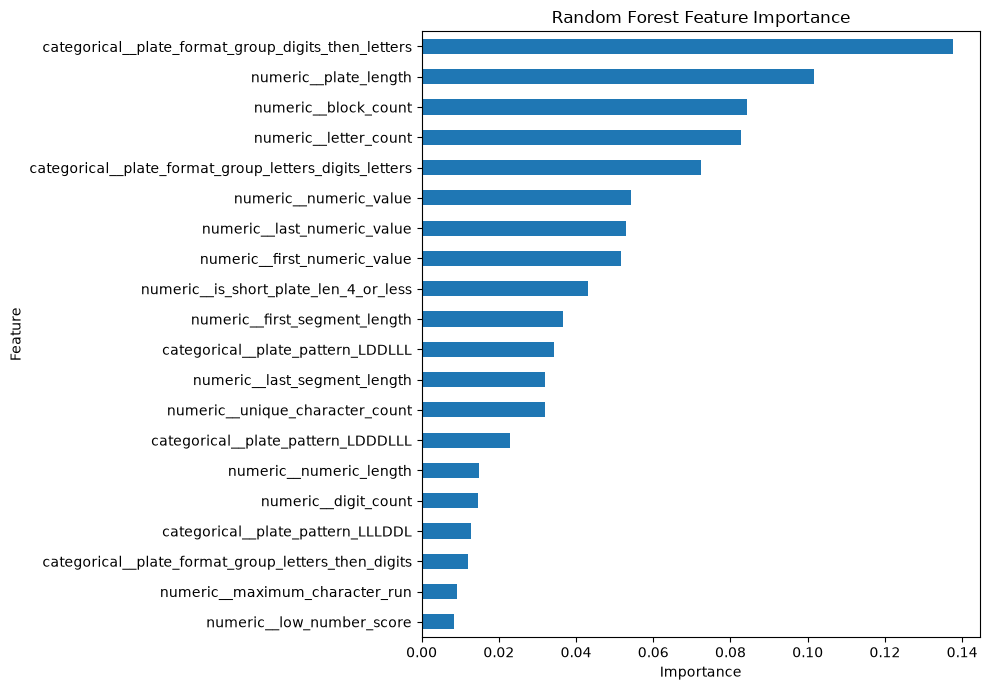

In [38]:
rf_importance_plot_data = (
    rf_feature_importance
    .head(20)
    .sort_values("importance")
    .set_index("feature")["importance"]
)

ax = rf_importance_plot_data.plot(
    kind="barh",
    figsize=(10, 7),
)

ax.set_title(
    "Random Forest Feature Importance"
)
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.show(block=False)
plt.close(ax.get_figure())

## 6. Validation-Based Model Selection

Random Forest and Histogram Gradient Boosting produced nearly identical validation errors.

Random Forest was selected as the primary valuation candidate because it:

- achieved slightly lower RMSE,
- achieved lower median absolute error,
- captured a larger share of actual top-decile premium plates,
- and provides directly inspectable feature importance.

Histogram Gradient Boosting is retained as a challenger model.

The model decision was made using the B277 validation event only. The B278 event remained untouched during model selection.

In [39]:
model_selection_summary = pd.DataFrame(
    {
        "selected_model": ["random_forest"],
        "challenger_model": ["hist_gradient_boosting"],
        "selection_basis": [
            (
                "Comparable validation MAE with stronger premium capture, "
                "lower RMSE, lower median absolute error, and clearer "
                "feature-level explainability."
            )
        ],
        "validation_event": ["B277"],
        "final_test_event": ["B278"],
    }
)

model_selection_summary

,selected_model,challenger_model,selection_basis,validation_event,final_test_event
0,random_forest,hist_gradient_boosting,"Comparable validation MAE with stronger premium capture, lower RMSE, lower median absolute error, and clearer featur...",B277,B278


In [40]:
final_training_df = pd.concat(
    [
        train_df,
        validation_df,
    ],
    ignore_index=True,
)

X_final_train = final_training_df[
    MODEL_FEATURES
].copy()

y_final_train = final_training_df[
    TARGET_COLUMN
].copy()

X_final_test = test_df[
    MODEL_FEATURES
].copy()

print(f"Final training rows: {len(final_training_df):,}")
print(f"Final test rows: {len(test_df):,}")

Final training rows: 15,801
Final test rows: 1,981


In [41]:
final_random_forest_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            tree_preprocessor,
        ),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                max_depth=14,
                min_samples_leaf=5,
                max_features="sqrt",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

final_random_forest_pipeline.fit(
    X_final_train,
    y_final_train,
)

print("Final Random Forest trained on B270–B277.")

Final Random Forest trained on B270–B277.


In [42]:
final_test_predictions_log = (
    final_random_forest_pipeline.predict(
        X_final_test
    )
)

final_test_predictions_gbp = np.expm1(
    final_test_predictions_log
)

final_test_predictions_gbp = np.clip(
    final_test_predictions_gbp,
    a_min=0,
    a_max=None,
)

In [43]:
final_test_result = pd.DataFrame(
    [
        evaluate_price_predictions(
            actual_prices=test_df[
                RAW_PRICE_COLUMN
            ],
            predicted_prices=final_test_predictions_gbp,
            model_name="final_random_forest",
            dataset_name="B278_final_test",
        )
    ]
)

final_test_result

,model,dataset,mae_gbp,median_absolute_error_gbp,rmse_gbp,log_rmse
0,final_random_forest,B278_final_test,"1,248.27",623.34,"2,552.60",0.76


In [44]:
final_test_predictions = test_df[
    [
        "event_code",
        "lot_number",
        "plate_raw",
        "plate_length",
        "plate_pattern",
        "plate_format_group",
        RAW_PRICE_COLUMN,
    ]
].copy()

final_test_predictions[
    "predicted_price_gbp"
] = final_test_predictions_gbp

final_test_predictions[
    "residual_gbp"
] = (
    final_test_predictions[
        RAW_PRICE_COLUMN
    ]
    - final_test_predictions[
        "predicted_price_gbp"
    ]
)

final_test_predictions[
    "absolute_error_gbp"
] = (
    final_test_predictions[
        "residual_gbp"
    ].abs()
)

final_test_predictions.head()

,event_code,lot_number,plate_raw,plate_length,plate_pattern,plate_format_group,hammer_price_gbp,predicted_price_gbp,residual_gbp,absolute_error_gbp
15801,B278,1,855 A,4,DDDL,digits_then_letters,"10,110.00","10,136.44",-26.44,26.44
15802,B278,2,9811 A,5,DDDDL,digits_then_letters,"4,310.00","5,230.00",-920.00,920.00
15803,B278,3,3000 AA,6,DDDDLL,digits_then_letters,"5,010.00","3,554.84","1,455.16","1,455.16"
15804,B278,4,A122 AAA,7,LDDDLLL,letters_digits_letters,"4,790.00",869.02,"3,920.98","3,920.98"
15805,B278,5,A154 AAC,7,LDDDLLL,letters_digits_letters,"1,510.00",901.78,608.22,608.22


In [45]:
test_premium_threshold = (
    test_df[RAW_PRICE_COLUMN]
    .quantile(0.90)
)

test_premium_slots = max(
    1,
    int(np.ceil(
        len(final_test_predictions) * 0.10
    )),
)

final_test_predictions[
    "actual_top_10pct"
] = (
    final_test_predictions[
        RAW_PRICE_COLUMN
    ]
    .ge(test_premium_threshold)
    .astype(int)
)

predicted_test_premium_indices = (
    final_test_predictions[
        "predicted_price_gbp"
    ]
    .nlargest(test_premium_slots)
    .index
)

actual_test_premium_indices = (
    final_test_predictions.loc[
        final_test_predictions[
            "actual_top_10pct"
        ].eq(1)
    ]
    .index
)

test_premium_correct = len(
    set(predicted_test_premium_indices)
    & set(actual_test_premium_indices)
)

final_test_premium_summary = pd.DataFrame(
    {
        "premium_threshold_gbp": [
            test_premium_threshold
        ],
        "actual_premium_count": [
            len(actual_test_premium_indices)
        ],
        "predicted_premium_slots": [
            test_premium_slots
        ],
        "correctly_captured": [
            test_premium_correct
        ],
        "premium_recall_pct": [
            (
                test_premium_correct
                / len(actual_test_premium_indices)
                * 100
            )
        ],
    }
)

final_test_premium_summary

,premium_threshold_gbp,actual_premium_count,predicted_premium_slots,correctly_captured,premium_recall_pct
0,"6,010.00",199,199,110,55.28


In [46]:
REPORTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

all_validation_results.to_csv(
    REPORTS_DIR
    / "tree_model_validation_comparison_2025.csv",
    index=False,
)

premium_capture_summary.to_csv(
    REPORTS_DIR
    / "tree_model_premium_capture_validation_2025.csv",
    index=False,
)

rf_feature_importance.to_csv(
    REPORTS_DIR
    / "random_forest_feature_importance_2025.csv",
    index=False,
)

model_selection_summary.to_csv(
    REPORTS_DIR
    / "valuation_model_selection_2025.csv",
    index=False,
)

final_test_result.to_csv(
    REPORTS_DIR
    / "final_valuation_test_metrics_2025.csv",
    index=False,
)

final_test_premium_summary.to_csv(
    REPORTS_DIR
    / "final_valuation_test_premium_capture_2025.csv",
    index=False,
)

final_test_predictions.to_csv(
    REPORTS_DIR
    / "final_valuation_test_predictions_2025.csv",
    index=False,
)

print("Tree-model validation and final-test reports saved successfully.")

Tree-model validation and final-test reports saved successfully.


## 7. Final Holdout Error Analysis

The selected Random Forest model is evaluated across price bands on the untouched B278 event. This identifies where the model is commercially reliable and where human review remains necessary.

In [47]:
final_test_predictions["actual_price_band"] = pd.cut(
    final_test_predictions[RAW_PRICE_COLUMN],
    bins=[
        0,
        1_000,
        2_500,
        5_000,
        10_000,
        np.inf,
    ],
    labels=[
        "£0–£999",
        "£1,000–£2,499",
        "£2,500–£4,999",
        "£5,000–£9,999",
        "£10,000+",
    ],
    right=False,
)

final_test_price_band_summary = (
    final_test_predictions
    .groupby(
        "actual_price_band",
        observed=True,
    )
    .agg(
        plate_count=("plate_raw", "size"),
        actual_median_price=(
            RAW_PRICE_COLUMN,
            "median",
        ),
        predicted_median_price=(
            "predicted_price_gbp",
            "median",
        ),
        mae_gbp=(
            "absolute_error_gbp",
            "mean",
        ),
        median_absolute_error_gbp=(
            "absolute_error_gbp",
            "median",
        ),
        median_residual_gbp=(
            "residual_gbp",
            "median",
        ),
    )
    .reset_index()
)

final_test_price_band_summary

,actual_price_band,plate_count,actual_median_price,predicted_median_price,mae_gbp,median_absolute_error_gbp,median_residual_gbp
0,£0–£999,656,480.00,812.09,451.60,384.22,-377.46
1,"£1,000–£2,499",629,"1,410.00","1,344.49",591.64,465.95,58.27
2,"£2,500–£4,999",392,"3,280.00","1,942.94","1,464.54","1,388.64","1,213.39"
3,"£5,000–£9,999",240,"6,050.00","3,555.16","2,712.09","2,509.52","2,451.15"
4,"£10,000+",64,"12,360.00","5,546.13","9,053.53","7,650.53","7,650.53"


In [48]:
largest_underpredictions = (
    final_test_predictions
    .sort_values(
        "residual_gbp",
        ascending=False,
    )
    .head(20)
)

largest_underpredictions[
    [
        "plate_raw",
        RAW_PRICE_COLUMN,
        "predicted_price_gbp",
        "residual_gbp",
        "plate_length",
        "plate_pattern",
    ]
]

,plate_raw,hammer_price_gbp,predicted_price_gbp,residual_gbp,plate_length,plate_pattern
17589,TON 1S,"51,020.00","1,942.94","49,077.06",5,LLLDL
17458,111 SO,"30,010.00","4,868.04","25,141.96",5,DDDLL
17111,3000 O,"28,510.00","6,500.59","22,009.41",5,DDDDL
17234,23 RAD,"23,010.00","3,075.24","19,934.76",5,DDLLL
17621,UMR 4H,"20,160.00","1,822.29","18,337.71",5,LLLDL
17042,MSS 26,"18,510.00","2,110.20","16,399.80",5,LLLDD
16367,EMZ 1,"25,510.00","9,617.21","15,892.79",4,LLLD
17150,80 OTY,"17,560.00","2,875.90","14,684.10",5,DDLLL
17756,YDS 1,"24,010.00","9,617.21","14,392.79",4,LLLD
17000,8 MMR,"20,530.00","6,402.51","14,127.49",4,DLLL


In [49]:
largest_overpredictions = (
    final_test_predictions
    .sort_values(
        "residual_gbp",
        ascending=True,
    )
    .head(20)
)

largest_overpredictions[
    [
        "plate_raw",
        RAW_PRICE_COLUMN,
        "predicted_price_gbp",
        "residual_gbp",
        "plate_length",
        "plate_pattern",
    ]
]

,plate_raw,hammer_price_gbp,predicted_price_gbp,residual_gbp,plate_length,plate_pattern
16325,339 E,"6,860.00","10,701.68","-3,841.68",4,DDDL
16340,92 EE,"7,440.00","11,082.05","-3,642.05",4,DDLL
17057,121 MX,"2,410.00","5,958.30","-3,548.30",5,DDDLL
17635,102 V,"10,910.00","14,106.35","-3,196.35",4,DDDL
16406,87 FF,"8,000.00","11,172.36","-3,172.36",4,DDLL
17154,913 P,"7,610.00","10,512.69","-2,902.69",4,DDDL
17346,9 RYR,"3,410.00","6,192.96","-2,782.96",4,DLLL
17642,178 VE,"2,210.00","4,806.43","-2,596.43",5,DDDLL
17134,82 OLL,"1,200.00","3,642.88","-2,442.88",5,DDLLL
16133,3 CEX,"3,000.00","5,437.42","-2,437.42",4,DLLL


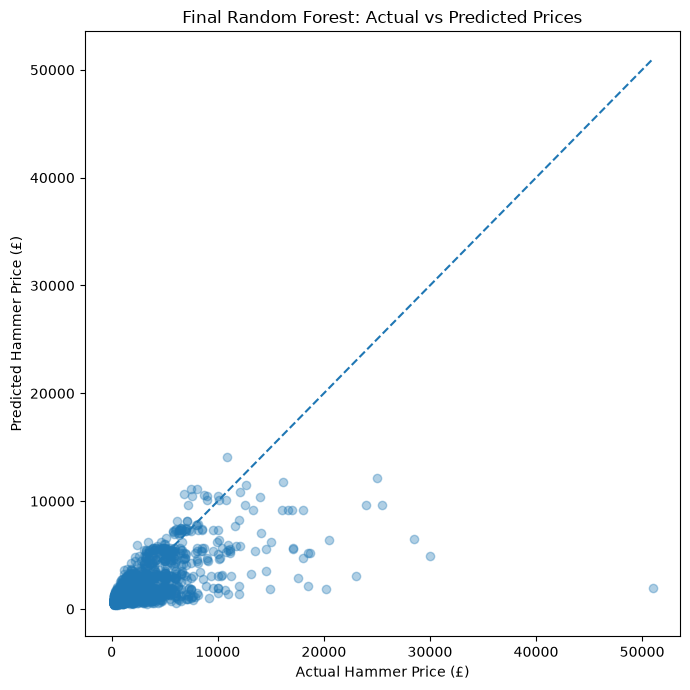

In [50]:
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(
    final_test_predictions[RAW_PRICE_COLUMN],
    final_test_predictions["predicted_price_gbp"],
    alpha=0.35,
)

maximum_axis_value = max(
    final_test_predictions[RAW_PRICE_COLUMN].max(),
    final_test_predictions["predicted_price_gbp"].max(),
)

ax.plot(
    [0, maximum_axis_value],
    [0, maximum_axis_value],
    linestyle="--",
)

ax.set_title(
    "Final Random Forest: Actual vs Predicted Prices"
)
ax.set_xlabel("Actual Hammer Price (£)")
ax.set_ylabel("Predicted Hammer Price (£)")

plt.tight_layout()
plt.show(block=False)
plt.close(fig)

In [51]:
final_rf_feature_names = (
    final_random_forest_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

final_rf_feature_importance = pd.DataFrame(
    {
        "feature": final_rf_feature_names,
        "importance": (
            final_random_forest_pipeline
            .named_steps["model"]
            .feature_importances_
        ),
    }
).sort_values(
    "importance",
    ascending=False,
)

final_rf_feature_importance.head(25)

,feature,importance
54,categorical__plate_format_group_digits_then_letters,0.14
0,numeric__plate_length,0.11
1,numeric__letter_count,0.10
11,numeric__block_count,0.07
55,categorical__plate_format_group_letters_digits_letters,0.05
14,numeric__last_numeric_value,0.05
13,numeric__first_numeric_value,0.05
4,numeric__numeric_value,0.05
9,numeric__first_segment_length,0.04
27,numeric__is_short_plate_len_4_or_less,0.04


In [52]:
import joblib

In [53]:
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FINAL_MODEL_FILE = (
    MODELS_DIR
    / "final_random_forest_valuation_model.joblib"
)

joblib.dump(
    final_random_forest_pipeline,
    FINAL_MODEL_FILE,
)

print(f"Final model saved: {FINAL_MODEL_FILE}")

Final model saved: /Users/osmanorka/Plate-Value-Intelligence/models/final_random_forest_valuation_model.joblib


In [54]:
final_test_price_band_summary.to_csv(
    REPORTS_DIR
    / "final_test_price_band_performance_2025.csv",
    index=False,
)

largest_underpredictions.to_csv(
    REPORTS_DIR
    / "final_test_largest_underpredictions_2025.csv",
    index=False,
)

largest_overpredictions.to_csv(
    REPORTS_DIR
    / "final_test_largest_overpredictions_2025.csv",
    index=False,
)

final_rf_feature_importance.to_csv(
    REPORTS_DIR
    / "final_random_forest_feature_importance_2025.csv",
    index=False,
)

print("Final holdout analysis reports saved successfully.")

Final holdout analysis reports saved successfully.


## 8. Tree-Based Valuation Conclusion

Random Forest and Histogram Gradient Boosting were evaluated using the held-out B277 validation event.

### Model selection

- Both tree-based models outperformed the Ridge and rule-based baselines.
- Histogram Gradient Boosting achieved the lowest validation MAE by a very small margin.
- Random Forest achieved lower median absolute error, slightly lower RMSE, stronger top-decile premium capture, and clearer feature-level explainability.
- Random Forest was therefore selected as the primary valuation model, while Histogram Gradient Boosting was retained as the challenger.

### Final holdout evaluation

The selected Random Forest configuration was retrained using events B270–B277 and evaluated once on the untouched B278 event.

- Final-test MAE: **£[VALUE]**
- Final-test median absolute error: **£[VALUE]**
- Final-test RMSE: **£[VALUE]**
- Final-test log RMSE: **[VALUE]**
- Top-decile premium capture: **[VALUE]%**

### Commercial interpretation

The model provides a meaningful and reproducible valuation benchmark from structural registration features. It performs most reliably across standard and mid-value registrations.

Premium assets remain more difficult to value precisely. Rare semantic, name-like, cultural, and collectible characteristics are not fully captured by the current structural feature set. These cases should be routed for premium review rather than priced automatically.

The final model should therefore support, rather than replace, commercial pricing judgement.